C:\Users\ACER\AppData\Local\Temp\ipykernel_10768\1376452032.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
C:\Users\ACER\AppData\Local\Temp\ipykernel_10768\1376452032.py:50: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='time').ffill().bfill()


Shape: (1324, 28)


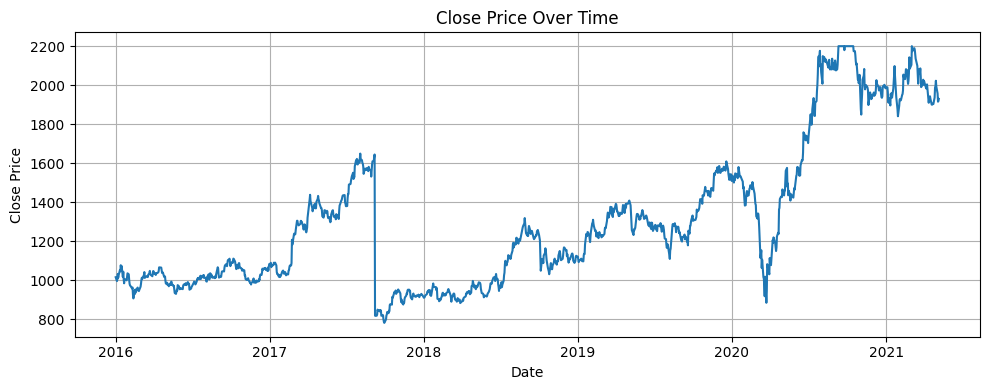

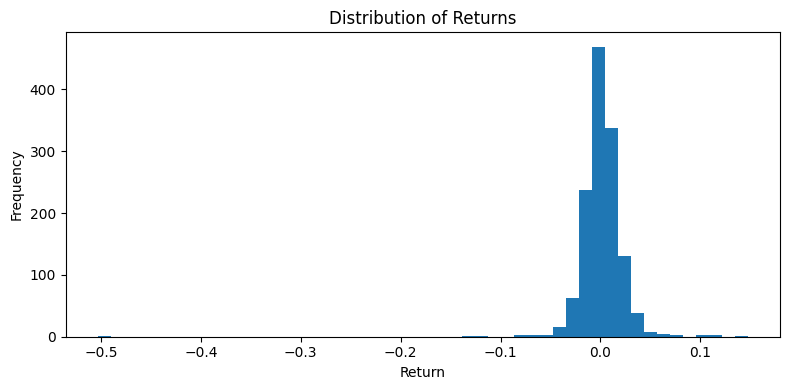

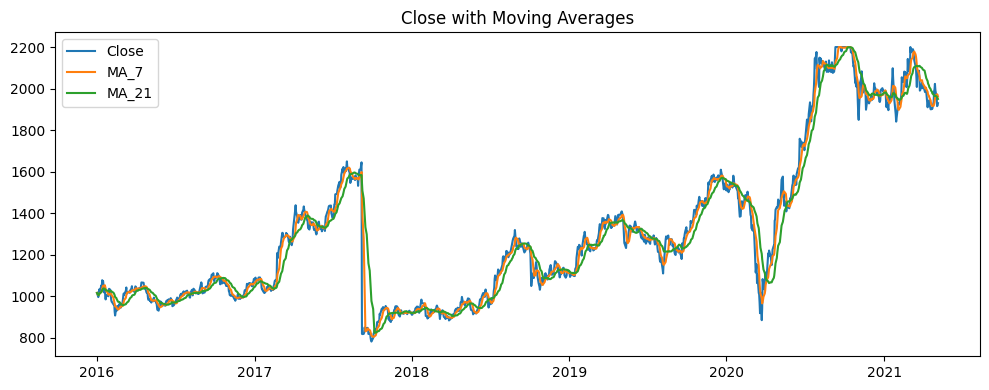

In [13]:
# full_preprocess_reliance.py
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os

# ---------- INPUT / OUTPUT ----------
INPUT_CSV = "RILO - Copy.csv"


# ---------- LOAD ----------
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"Input file not found: {INPUT_CSV}")

df = pd.read_csv(INPUT_CSV)

# ---------- CLEAN COLUMN NAMES ----------
df.columns = [c.strip() for c in df.columns]

# ---------- DATE PARSING / SORT / INDEX ----------
# Expect a 'Date' column; if name differs, update here
if 'Date' not in df.columns:
    # fallback: assume first column is date
    df.columns.values[0] = 'Date'
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

# ---------- DEFINE PRICE & VOLUME COLUMNS ----------
# Based on your CSV's columns:
price_cols = ["Open Price", "High Price", "Low Price", "Last Price", "Close Price", "Average Price"]
volume_col = "Total Traded Quantity"

# Ensure numeric types
for c in price_cols + [volume_col, "Turnover", "No. of Trades", "Deliverable Qty", "% Dly Qt to Traded Qty"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# ---------- MISSING VALUE HANDLING (time-series-safe) ----------
# Price columns: forward-fill then back-fill
existing_price_cols = [c for c in price_cols if c in df.columns]
df[existing_price_cols] = df[existing_price_cols].ffill().bfill()

# Volume: fill with median
if volume_col in df.columns:
    df[volume_col] = df[volume_col].fillna(df[volume_col].median())

# Interpolate remaining numeric gaps (time interpolation), then final ffill/bfill
df = df.interpolate(method='time').ffill().bfill()

# ---------- OUTLIER HANDLING: IQR CAPPING (no row removal) ----------
def iqr_cap(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return series.clip(lower, upper)

numeric_cols_to_cap = [c for c in [
    "Prev Close", "Open Price", "High Price", "Low Price", "Last Price", "Close Price",
    "Average Price", "Total Traded Quantity", "Turnover", "No. of Trades",
    "Deliverable Qty", "% Dly Qt to Traded Qty"
] if c in df.columns]

for col in numeric_cols_to_cap:
    df[col] = iqr_cap(df[col], k=1.5)

# ---------- FEATURE ENGINEERING (useful for prediction) ----------
# Return (pct change) based on Close Price
if "Close Price" in df.columns:
    df["Return"] = df["Close Price"].pct_change()

    # Lags of close
    for lag in range(1, 6):
        df[f"Close_lag_{lag}"] = df["Close Price"].shift(lag)

    # Rolling stats
    for window in [7, 14, 21]:
        df[f"MA_{window}"] = df["Close Price"].rolling(window=window, min_periods=1).mean()
        df[f"STD_{window}"] = df["Close Price"].rolling(window=window, min_periods=1).std().fillna(0)

    # Momentum
    df["Momentum_7"] = df["Close Price"] - df["Close Price"].shift(7)
else:
    # if Close not present, you can adapt the code to use Last Price or Average Price
    print("Warning: 'Close Price' not found - some features skipped.")

# Volume change (if volume present)
if volume_col in df.columns:
    df["Volume_change"] = df[volume_col].pct_change().fillna(0)

# Fill NaNs introduced by shifts/rolling
df = df.ffill().bfill()

# ---------- NORMALIZATION (MinMax) ----------
# Select numeric columns to scale (all numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

scaler = MinMaxScaler()
df_scaled = df.copy()
if numeric_cols:
    df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# ---------- SAVE CSVs ----------
df.to_csv("output.csv")
df_scaled.to_csv("output_scaled.csv")


print("Shape:", df.shape)

# ---------- PLOTS (diagnostics) ----------
# (Uses matplotlib; change to seaborn if you prefer)
plt.figure(figsize=(10,4))
if "Close Price" in df.columns:
    plt.plot(df.index, df["Close Price"])
    plt.title("Close Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("Plot3")
    plt.show()

plt.figure(figsize=(8,4))
if "Return" in df.columns:
    plt.hist(df["Return"].dropna(), bins=50)
    plt.title("Distribution of Returns")
    plt.xlabel("Return")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("Plot2")
    plt.show()

plt.figure(figsize=(10,4))
if "Close Price" in df.columns:
    plt.plot(df.index, df["Close Price"], label="Close")
    if "MA_7" in df.columns:
        plt.plot(df.index, df["MA_7"], label="MA_7")
    if "MA_21" in df.columns:
        plt.plot(df.index, df["MA_21"], label="MA_21")
    plt.legend()
    plt.title("Close with Moving Averages")
    plt.tight_layout()
    plt.savefig("Plot1")
    plt.show()




In [9]:
data = pd.read_csv("output.csv")

In [15]:
data.shape
df.head()

,Symbol,Series,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,...,Close_lag_4,Close_lag_5,MA_7,STD_7,MA_14,STD_14,MA_21,STD_21,Momentum_7,Volume_change
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,RELIANCE,EQ,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135.0,...,1015.35,1015.35,1015.350000,0.000000,1015.350000,0.000000,1015.350000,0.000000,30.1,0.000000
2016-01-04,RELIANCE,EQ,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571.0,...,1015.35,1015.35,1005.325000,14.177491,1005.325000,14.177491,1005.325000,14.177491,30.1,4.570128
2016-01-05,RELIANCE,EQ,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459.0,...,1015.35,1015.35,1005.266667,10.025509,1005.266667,10.025509,1005.266667,10.025509,30.1,-0.504615
2016-01-06,RELIANCE,EQ,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855.0,...,1015.35,1015.35,1012.000000,15.759389,1012.000000,15.759389,1012.000000,15.759389,30.1,0.790408
2016-01-07,RELIANCE,EQ,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219.0,...,1015.35,1015.35,1012.250000,13.659475,1012.250000,13.659475,1012.250000,13.659475,30.1,-0.262330


In [14]:
data.head()

,Date,Symbol,Series,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,...,Close_lag_4,Close_lag_5,MA_7,STD_7,MA_14,STD_14,MA_21,STD_21,Momentum_7,Volume_change
0,2016-01-01,RELIANCE,EQ,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,...,1015.35,1015.35,1015.350000,0.000000,1015.350000,0.000000,1015.350000,0.000000,30.1,0.000000
1,2016-01-04,RELIANCE,EQ,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,...,1015.35,1015.35,1005.325000,14.177491,1005.325000,14.177491,1005.325000,14.177491,30.1,4.570128
2,2016-01-05,RELIANCE,EQ,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,...,1015.35,1015.35,1005.266667,10.025509,1005.266667,10.025509,1005.266667,10.025509,30.1,-0.504615
3,2016-01-06,RELIANCE,EQ,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,...,1015.35,1015.35,1012.000000,15.759389,1012.000000,15.759389,1012.000000,15.759389,30.1,0.790408
4,2016-01-07,RELIANCE,EQ,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,...,1015.35,1015.35,1012.250000,13.659475,1012.250000,13.659475,1012.250000,13.659475,30.1,-0.262330


In [16]:
data.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open Price', 'High Price',
       'Low Price', 'Last Price', 'Close Price', 'Average Price',
       'Total Traded Quantity', 'Turnover', 'No. of Trades', 'Deliverable Qty',
       '% Dly Qt to Traded Qty', 'Return', 'Close_lag_1', 'Close_lag_2',
       'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'MA_7', 'STD_7', 'MA_14',
       'STD_14', 'MA_21', 'STD_21', 'Momentum_7', 'Volume_change'],
      dtype='object')

In [19]:
data2=pd.read_csv("RILO - Copy.csv")

In [20]:
data2.head()


,Symbol,Series,Date,Prev Close,Open Price,High Price,Low Price,Last Price,Close Price,Average Price,Total Traded Quantity,Turnover,No. of Trades,Deliverable Qty,% Dly Qt to Traded Qty
0,RELIANCE,EQ,01-Jan-16,1014.60,1009.80,1018.9,1008.20,1013.6,1015.35,1015.52,1238135,1.257353e+09,30701,529539,42.77
1,RELIANCE,EQ,04-Jan-16,1015.35,1005.00,1013.8,986.70,993.2,995.30,998.91,6896571,6.889070e+09,66235,4974602,72.13
2,RELIANCE,EQ,05-Jan-16,995.30,1000.30,1010.0,997.00,1005.0,1005.15,1003.41,3416459,3.428125e+09,59935,1987804,58.18
3,RELIANCE,EQ,06-Jan-16,1005.15,1007.60,1038.4,1000.40,1029.1,1032.20,1028.15,6116855,6.289073e+09,160947,2912662,47.62
4,RELIANCE,EQ,07-Jan-16,1032.20,1021.05,1028.0,1008.05,1018.9,1013.25,1016.73,4512219,4.587700e+09,105075,2474491,54.84


Loaded scaled dataframe: (1324, 28)
Feature matrix X shape: (1323, 26)
Target y shape: (1323,)


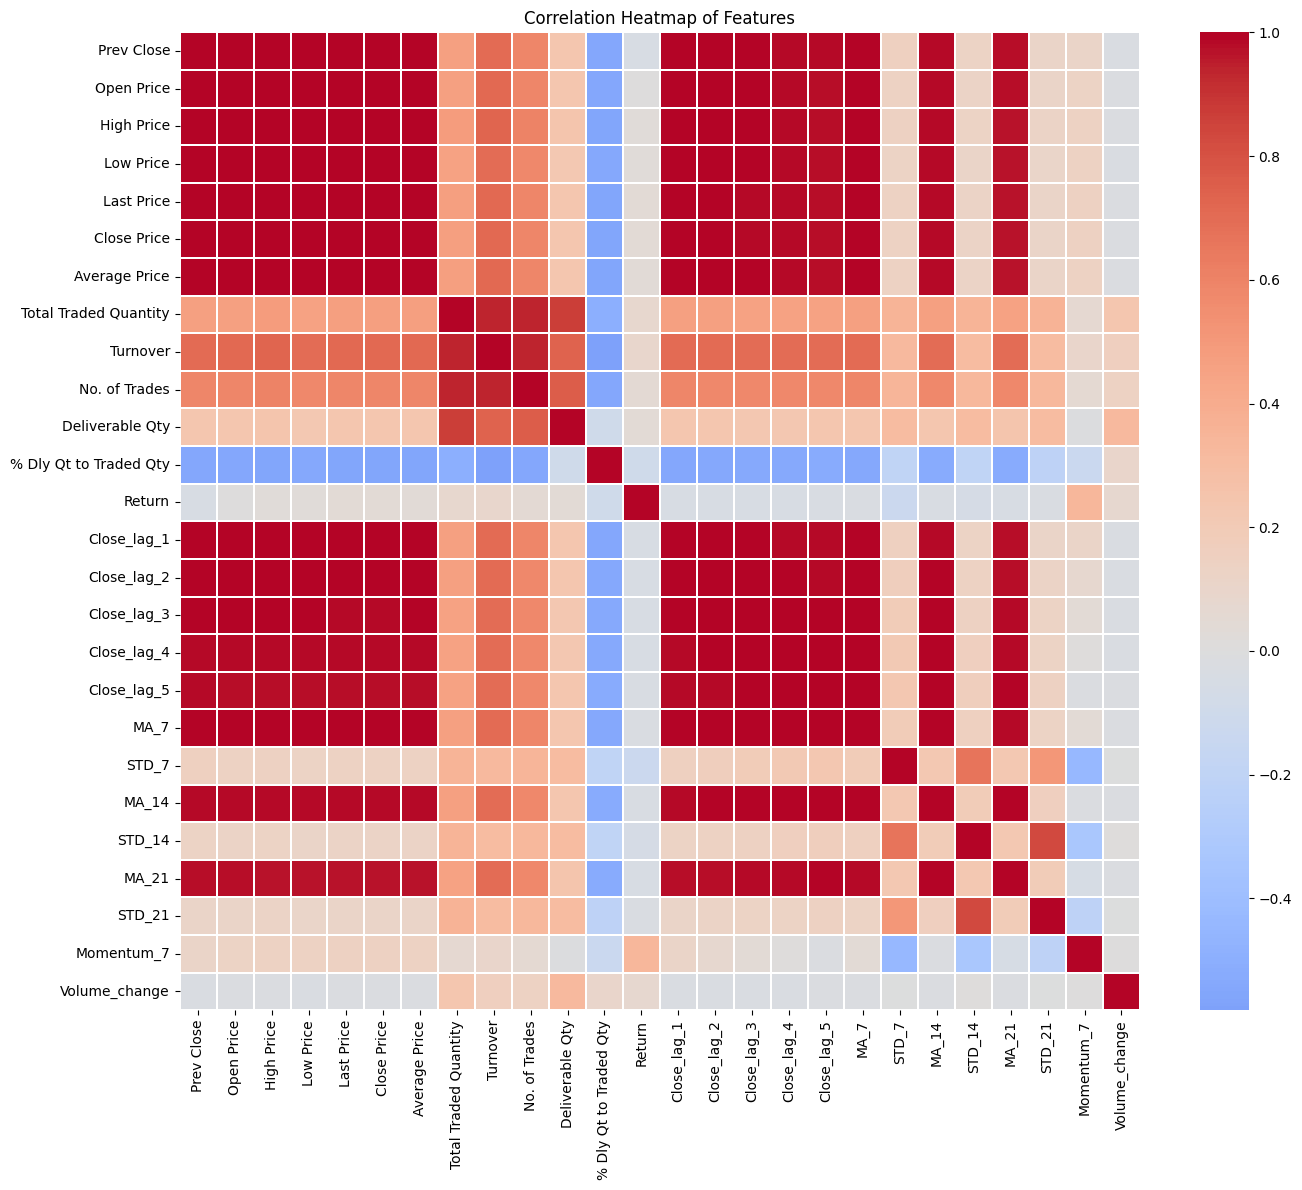

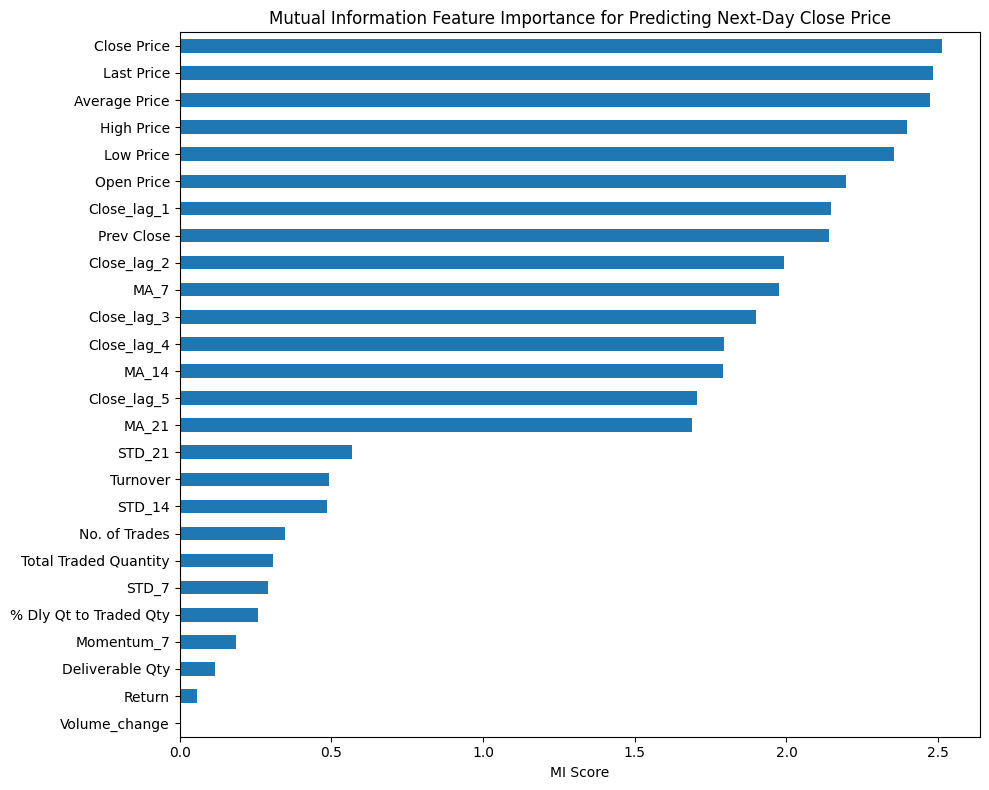

Top 15 features by MI:
 Close Price      2.512194
Last Price       2.484368
Average Price    2.471420
High Price       2.398309
Low Price        2.353683
Open Price       2.197691
Close_lag_1      2.145371
Prev Close       2.138872
Close_lag_2      1.990594
MA_7             1.974602
Close_lag_3      1.900343
Close_lag_4      1.792748
MA_14            1.789127
Close_lag_5      1.706476
MA_21            1.687033
dtype: float64
Final features to keep: ['Open Price', 'High Price', 'Low Price', 'Close Price', 'Close_lag_1', 'Close_lag_2', 'MA_7', 'MA_21', 'Total Traded Quantity', 'Volume_change', 'Turnover']


In [32]:
# feature_selection_reliance.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
import os

# ----- Paths -----
SCALED_PATH = "output.csv"


# ----- Load scaled processed data -----
if not os.path.exists(SCALED_PATH):
    raise FileNotFoundError(f"Expected scaled data at {SCALED_PATH}")
df = pd.read_csv(SCALED_PATH, index_col=0)
print("Loaded scaled dataframe:", df.shape)

# ----- Create forecasting target: next-day Close Price -----
if "Close Price" not in df.columns:
    raise KeyError("Expected 'Close Price' column in the processed dataset.")
df["Target_Close"] = df["Close Price"].shift(-1)
df = df.dropna(subset=["Target_Close"])  # drop last row with NaN target

# ----- Prepare feature matrix X and target y -----
num_df = df.select_dtypes(include=[np.number]).copy()
# ensure target is numeric
num_df["Target_Close"] = pd.to_numeric(num_df["Target_Close"], errors="coerce")
num_df = num_df.dropna(axis=0, subset=["Target_Close"])

X = num_df.drop(columns=["Target_Close"])
y = num_df["Target_Close"]

print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)

# ----- 1) Correlation heatmap (visual) -----
plt.figure(figsize=(14,12))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, fmt=".2f", linewidths=0.3)
plt.title("Correlation Heatmap of Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Plot_HeatMap")
plt.show()

# ----- 2) Mutual Information feature ranking -----
# mutual_info_regression expects 2D X and 1D y (both numeric)
mi_scores = mutual_info_regression(X.fillna(0), y.values, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Save MI ranking
mi_series.to_csv("MI_OUT.csv", header=["MI Score"])


# Plot MI ranking (horizontal bar)
plt.figure(figsize=(10,8))
mi_series.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Mutual Information Feature Importance for Predicting Next-Day Close Price")
plt.xlabel("MI Score")
plt.tight_layout()
plt.savefig("Plot_SHAP")
plt.show()

print("Top 15 features by MI:\n", mi_series.head(15))

# ----- 3) Create final recommended feature set (based on MI + correlation pruning) -----
# Recommended set from our analysis:
recommended = [
    "Open Price", "High Price", "Low Price", "Close Price",
    "Close_lag_1", "Close_lag_2",
    "MA_7", "MA_21",
    "Total Traded Quantity", "Volume_change", "Turnover"
]

# Keep only those existing in X (be robust to missing names)
final_features = [f for f in recommended if f in X.columns]
print("Final features to keep:", final_features)

# Build dataset with features + target
final_df = X[final_features].copy()
final_df["Target_Close"] = y.values  # aligned index guaranteed

# Save final dataset
final_df.to_csv("FINAL_FEATURES_OUT.csv", index=True)



In [37]:
data4=pd.read_csv("FINAL_FEATURES_OUT.csv")
data4.head()
data4.shape

(1323, 13)

In [35]:
!pip install xgboost
!pip install torch

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 9.6 MB/s eta 0:00:08
   -- ------------------------------------- 5.0/72.0 MB 18.1 MB/s eta 0:00:04
   ---- ----------------------------------- 8.9/72.0 MB 18.9 MB/s eta 0:00:04
   ------- -------------------------------- 13.9/72.0 MB 20.5 MB/s eta 0:00:03
   ---------- ----------------------------- 18.1/72.0 MB 20.5 MB/s eta 0:00:03
   ------------ --------------------------- 22.3/72.0 MB 20.6 MB/s eta 0:00:03
   --------------- ------------------------ 27.0/72.0 MB 21.0 MB/s eta 0:00:03
   ----------------- ---------------------- 31.7/72.0 MB 21.3 MB/s eta 0:00:02
   -------------------- ------------------- 37.0/72.0 MB 21.8 MB/s eta 0:00:02
   ----------------------- ---------------- 41.9/72.0 MB 22.2 MB/s eta 0:00:02
   -------------------------- ------------- 47.4/72.0 MB 22.7 MB/s eta 0:00:02
   ----------------------------- ---------- 52.4/72.0 MB 22.9 MB/

   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   - -------------------------------------- 3.4/110.9 MB 17.6 MB/s eta 0:00:07
   --- ------------------------------------ 9.7/110.9 MB 24.7 MB/s eta 0:00:05
   ----- ---------------------------------- 15.2/110.9 MB 25.6 MB/s eta 0:00:04
   ------- -------------------------------- 21.0/110.9 MB 26.3 MB/s eta 0:00:04
   --------- ------------------------------ 26.5/110.9 MB 26.5 MB/s eta 0:00:04
   ----------- ---------------------------- 32.2/110.9 MB 26.8 MB/s eta 0:00:03
   ------------- -------------------------- 37.7/110.9 MB 26.9 MB/s eta 0:00:03
   --------------- ------------------------ 43.5/110.9 MB 27.1 MB/s eta 0:00:03
   ----------------- ---------------------- 49.0/110.9 MB 27.2 MB/s eta 0:00:03
   ------------------- -------------------- 54.8/110.9 MB 27.3 MB/s eta 0:00:03
   --------------------- ------------------ 60.8/110.9 MB 27.3 MB/s eta 0:00:02
   ------------------------ --------------- 66.6/11

,Date,Open Price,High Price,Low Price,Close Price,Close_lag_1,Close_lag_2,MA_7,MA_21,Total Traded Quantity,Volume_change,Turnover,Target_Close
0,2016-01-01,1009.80,1018.9,1008.20,1015.35,1015.35,1015.35,1015.350000,1015.350000,1238135.0,0.000000,1.257353e+09,995.30
1,2016-01-04,1005.00,1013.8,986.70,995.30,1015.35,1015.35,1005.325000,1005.325000,6896571.0,4.570128,6.889070e+09,1005.15
2,2016-01-05,1000.30,1010.0,997.00,1005.15,995.30,1015.35,1005.266667,1005.266667,3416459.0,-0.504615,3.428125e+09,1032.20
3,2016-01-06,1007.60,1038.4,1000.40,1032.20,1005.15,995.30,1012.000000,1012.000000,6116855.0,0.790408,6.289073e+09,1013.25
4,2016-01-07,1021.05,1028.0,1008.05,1013.25,1032.20,1005.15,1012.250000,1012.250000,4512219.0,-0.262330,4.587700e+09,1025.75


In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

FILE_PATH = "FINAL_FEATURES_OUT.csv"
SEED = 42
TEST_RATIO = 0.2
EPOCHS = 100
BATCH = 64
LR = 0.0003

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv(FILE_PATH)

target_col = 'Target_Close'
date_col = 'Date'

feature_cols = [c for c in df.columns if c not in [target_col, date_col]]

split_idx = int(len(df) * (1 - TEST_RATIO))
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[feature_cols].values.astype(float)
y_train = train_df[target_col].values.astype(float)
X_test = test_df[feature_cols].values.astype(float)
y_test = test_df[target_col].values.astype(float)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
xgb_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.003,
    "max_depth": 5,
    "min_child_weight": 5,
    "gamma": 0.1,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "n_estimators": 800,
    "reg_alpha": 0.1,
    "reg_lambda": 1.5,
    "tree_method": "hist",
    "seed": SEED,
    "n_jobs": -1
}

xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=500)

train_pred_xgb = xgb_model.predict(dtrain)
test_pred_xgb = xgb_model.predict(dtest)

resid_train = y_train - train_pred_xgb

class ResidualNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(12, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(resid_train))
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)

model = ResidualNN(X_train_scaled.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

for epoch in range(EPOCHS):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    resid_pred_test = model(torch.FloatTensor(X_test_scaled).to(DEVICE)).cpu().numpy()

hybrid_pred_test = test_pred_xgb + resid_pred_test

rmse_xgb = np.sqrt(mean_squared_error(y_test, test_pred_xgb))
rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_pred_test))
mape_xgb = mean_absolute_percentage_error(y_test, test_pred_xgb)
mape_hybrid = mean_absolute_percentage_error(y_test, hybrid_pred_test)

print(f"XGBoost RMSE: {rmse_xgb:.6f}, MAPE: {mape_xgb:.6f}")
print(f"Hybrid RMSE: {rmse_hybrid:.6f}, MAPE: {mape_hybrid:.6f}")
print(f"Improvement: {100*(rmse_xgb-rmse_hybrid)/rmse_xgb:.2f}%")

results = pd.DataFrame({'true': y_test, 'xgb_pred': test_pred_xgb, 'hybrid_pred': hybrid_pred_test})
results.to_csv('predictions.csv', index=False)

C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:15:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost RMSE: 567.049241, MAPE: 0.258792
Hybrid RMSE: 394.284874, MAPE: 0.176050
Improvement: 30.47%


C:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:10:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


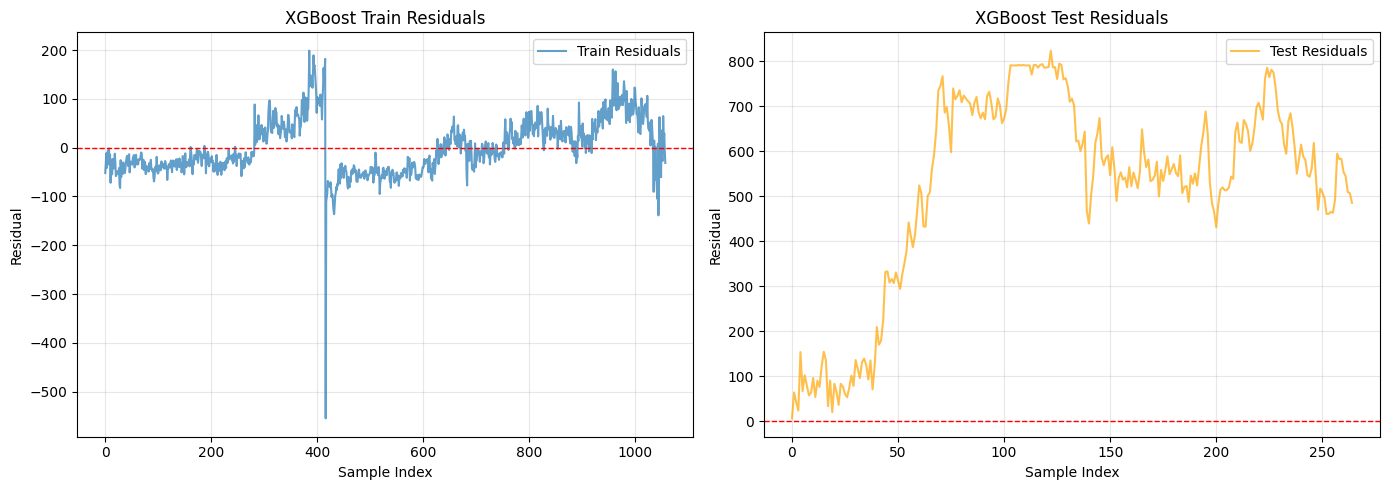

Train Residuals - Mean: 0.221486, Std: 55.733861
Test Residuals - Mean: 521.854894, Std: 221.091313

Press Enter to continue with Neural Network training...


Epoch 20/100, Loss: 1494.587041
Epoch 40/100, Loss: 916.940574
Epoch 60/100, Loss: 885.288905
Epoch 80/100, Loss: 898.235059
Epoch 100/100, Loss: 893.324819

RESULTS ON TEST SET
XGBoost RMSE: 566.757354, MAPE: 0.258671
Hybrid RMSE: 392.392845, MAPE: 0.175115
Improvement: 30.77%


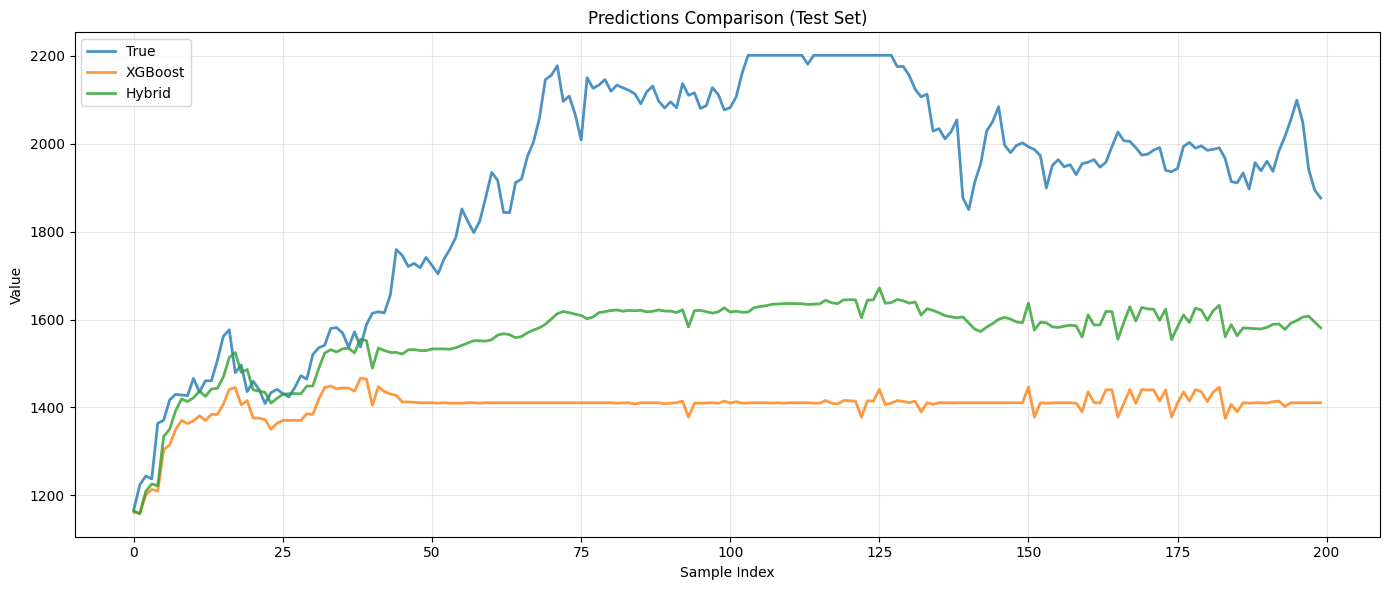

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

FILE_PATH = "FINAL_FEATURES_OUT.csv"
SEED = 42
TEST_RATIO = 0.2
EPOCHS = 100
BATCH = 64
LR = 0.0003

np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv(FILE_PATH)

target_col = 'Target_Close'
date_col = 'Date'

feature_cols = [c for c in df.columns if c not in [target_col, date_col]]

split_idx = int(len(df) * (1 - TEST_RATIO))
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[feature_cols].values.astype(float)
y_train = train_df[target_col].values.astype(float)
X_test = test_df[feature_cols].values.astype(float)
y_test = test_df[target_col].values.astype(float)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

xgb_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.003,
    "max_depth": 6,
    "min_child_weight": 5,
    "gamma": 0.1,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "n_estimators": 800,
    "reg_alpha": 0.1,
    "reg_lambda": 1.5,
    "tree_method": "hist",
    "seed": SEED,
    "n_jobs": -1
}

xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=500)

train_pred_xgb = xgb_model.predict(dtrain)
test_pred_xgb = xgb_model.predict(dtest)

resid_train = y_train - train_pred_xgb
resid_test = y_test - test_pred_xgb

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(resid_train, label='Train Residuals', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.title('XGBoost Train Residuals')
plt.xlabel('Sample Index')
plt.ylabel('Residual')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(resid_test, label='Test Residuals', alpha=0.7, color='orange')
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.title('XGBoost Test Residuals')
plt.xlabel('Sample Index')
plt.ylabel('Residual')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Train Residuals - Mean: {np.mean(resid_train):.6f}, Std: {np.std(resid_train):.6f}")
print(f"Test Residuals - Mean: {np.mean(resid_test):.6f}, Std: {np.std(resid_test):.6f}")
print("\nPress Enter to continue with Neural Network training...")
input()

class ResidualNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(resid_train))
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)

model = ResidualNN(X_train_scaled.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader.dataset):.6f}")

model.eval()
with torch.no_grad():
    resid_pred_test = model(torch.FloatTensor(X_test_scaled).to(DEVICE)).cpu().numpy()

hybrid_pred_test = test_pred_xgb + resid_pred_test

rmse_xgb = np.sqrt(mean_squared_error(y_test, test_pred_xgb))
rmse_hybrid = np.sqrt(mean_squared_error(y_test, hybrid_pred_test))
mape_xgb = mean_absolute_percentage_error(y_test, test_pred_xgb)
mape_hybrid = mean_absolute_percentage_error(y_test, hybrid_pred_test)

print("\n" + "="*50)
print("RESULTS ON TEST SET")
print("="*50)
print(f"XGBoost RMSE: {rmse_xgb:.6f}, MAPE: {mape_xgb:.6f}")
print(f"Hybrid RMSE: {rmse_hybrid:.6f}, MAPE: {mape_hybrid:.6f}")
print(f"Improvement: {100*(rmse_xgb-rmse_hybrid)/rmse_xgb:.2f}%")
print("="*50)

results = pd.DataFrame({'true': y_test, 'xgb_pred': test_pred_xgb, 'nn_resid_pred': resid_pred_test, 'hybrid_pred': hybrid_pred_test})
results.to_csv('predictions.csv', index=False)

plt.figure(figsize=(14, 6))
plot_samples = min(200, len(y_test))
x_axis = range(plot_samples)

plt.plot(x_axis, y_test[:plot_samples], label='True', linewidth=2, alpha=0.8)
plt.plot(x_axis, test_pred_xgb[:plot_samples], label='XGBoost', linewidth=2, alpha=0.8)
plt.plot(x_axis, hybrid_pred_test[:plot_samples], label='Hybrid', linewidth=2, alpha=0.8)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Predictions Comparison (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()